In [1]:
import pandas as pd
import random
from datetime import datetime, timedelta
import numpy as np

# Rastgelelik ayarı
np.random.seed(10)
random.seed(10)

# -----------------------------------------------------
# TABLO 1: MÜŞTERİLER TABLOSU (Primary Key: Musteri_ID)
# -----------------------------------------------------
musteri_id_listesi = [f"M{str(i).zfill(3)}" for i in range(1, 101)] # M001, M002 ... M100
isimler = ["Ahmet", "Ayşe", "Mehmet", "Fatma", "Ali", "Zeynep", "Hüseyin", "Elif", "Mustafa", "Canan"]
sehirler = ["İstanbul", "Ankara", "İzmir", "Bursa", "Antalya"]

musteriler_data = []
for m_id in musteri_id_listesi:
    musteriler_data.append({
        "Musteri_ID": m_id,
        "Ad": random.choice(isimler),
        "Sehir": random.choice(sehirler),
        "Kayıt_Tarihi": (datetime(2023, 1, 1) + timedelta(days=random.randint(0, 200))).strftime('%Y-%m-%d')
    })
df_musteriler = pd.DataFrame(musteriler_data)
df_musteriler.to_csv('tablo_musteriler.csv', index=False, encoding='utf-8-sig')


# -----------------------------------------------------
# TABLO 2: ÜRÜNLER TABLOSU (Primary Key: Urun_ID)
# -----------------------------------------------------
urun_id_listesi = [f"U{str(i).zfill(3)}" for i in range(1, 21)] # U001, U002 ... U020
kategoriler = ["Elektronik", "Giyim", "Kitap"]
urunler_data = []
for u_id in urun_id_listesi:
    kat = random.choice(kategoriler)
    fiyat = random.randint(1000, 5000) if kat == "Elektronik" else random.randint(100, 500)
    urunler_data.append({
        "Urun_ID": u_id,
        "Kategori": kat,
        "Birim_Fiyat": fiyat
    })
df_urunler = pd.DataFrame(urunler_data)
df_urunler.to_csv('tablo_urunler.csv', index=False, encoding='utf-8-sig')


# -----------------------------------------------------
# TABLO 3: SİPARİŞLER TABLOSU (Foreign Keys: Musteri_ID, Urun_ID)
# -----------------------------------------------------
# Bu tablo, diğer iki tabloyu birbirine bağlar.
siparisler_data = []
for i in range(1, 1501): # 1500 sipariş
    siparisler_data.append({
        "Siparis_ID": 5000 + i,
        "Musteri_ID": random.choice(musteri_id_listesi), # Müşteriler tablosundan referans
        "Urun_ID": random.choice(urun_id_listesi),       # Ürünler tablosundan referans
        "Siparis_Tarihi": (datetime(2023, 6, 1) + timedelta(days=random.randint(0, 150))).strftime('%Y-%m-%d'),
        "Adet": random.randint(1, 3)
    })
df_siparisler = pd.DataFrame(siparisler_data)
df_siparisler.to_csv('tablo_siparisler.csv', index=False, encoding='utf-8-sig')

print("Harika! İlişkisel Veritabanı mantığına uygun 3 farklı tablo oluşturuldu:")
print("1. tablo_musteriler.csv (100 Müşteri)")
print("2. tablo_urunler.csv (20 Ürün)")
print("3. tablo_siparisler.csv (1500 Sipariş - Diğer tablolarla ilişkili)")

Harika! İlişkisel Veritabanı mantığına uygun 3 farklı tablo oluşturuldu:
1. tablo_musteriler.csv (100 Müşteri)
2. tablo_urunler.csv (20 Ürün)
3. tablo_siparisler.csv (1500 Sipariş - Diğer tablolarla ilişkili)


In [2]:
import pandas as pd

print("1. Oluşturulan İlişkisel Tablolar Okunuyor...")
df_musteriler = pd.read_csv('tablo_musteriler.csv')
df_urunler = pd.read_csv('tablo_urunler.csv')
df_siparisler = pd.read_csv('tablo_siparisler.csv')

# -----------------------------------------------------
# ADIM 1: SİPARİŞLER ile MÜŞTERİLERİ Birleştirme
# SQL Karşılığı: INNER JOIN Musteriler ON Siparisler.Musteri_ID = Musteriler.Musteri_ID
# -----------------------------------------------------
print("2. Siparişler ve Müşteriler tabloları 'Musteri_ID' üzerinden birleştiriliyor (JOIN)...")
df_birlesik_1 = pd.merge(df_siparisler, df_musteriler, on='Musteri_ID', how='inner')

# -----------------------------------------------------
# ADIM 2: ÇIKAN SONUÇ ile ÜRÜNLERİ Birleştirme
# SQL Karşılığı: INNER JOIN Urunler ON df_birlesik_1.Urun_ID = Urunler.Urun_ID
# -----------------------------------------------------
print("3. Çıkan sonuç Ürünler tablosu ile 'Urun_ID' üzerinden birleştiriliyor...")
df_final = pd.merge(df_birlesik_1, df_urunler, on='Urun_ID', how='inner')

# -----------------------------------------------------
# ADIM 3: Analiz İçin Yeni Kolon Hesaplama (Ciro)
# -----------------------------------------------------
# Yöneticiler toplam ciroyu görmek ister. Fiyat ile Adeti çarpıyoruz.
df_final['Toplam_Tutar'] = df_final['Birim_Fiyat'] * df_final['Adet']

# Sütunların sırasını daha okunaklı hale getirelim
df_final = df_final[['Siparis_ID', 'Siparis_Tarihi', 'Musteri_ID', 'Ad', 'Sehir', 'Urun_ID', 'Kategori', 'Birim_Fiyat', 'Adet', 'Toplam_Tutar']]

# Dashboard'da kullanmak üzere final verisini kaydedelim
df_final.to_csv('Dashboard_Verisi.csv', index=False, encoding='utf-8-sig')

print("\nHarika! Tüm tablolar başarıyla birleştirildi (JOIN yapıldı).")
print("Görselleştirme için hazır olan 'Dashboard_Verisi.csv' dosyası oluşturuldu.")
print("\n--- Birleştirilmiş Veriden İlk 3 Satır ---")
print(df_final.head(3).to_string())

1. Oluşturulan İlişkisel Tablolar Okunuyor...
2. Siparişler ve Müşteriler tabloları 'Musteri_ID' üzerinden birleştiriliyor (JOIN)...
3. Çıkan sonuç Ürünler tablosu ile 'Urun_ID' üzerinden birleştiriliyor...

Harika! Tüm tablolar başarıyla birleştirildi (JOIN yapıldı).
Görselleştirme için hazır olan 'Dashboard_Verisi.csv' dosyası oluşturuldu.

--- Birleştirilmiş Veriden İlk 3 Satır ---
   Siparis_ID Siparis_Tarihi Musteri_ID       Ad     Sehir Urun_ID    Kategori  Birim_Fiyat  Adet  Toplam_Tutar
0        5001     2023-09-24       M061     Elif  İstanbul    U020       Giyim          461     3          1383
1        5002     2023-07-15       M057   Zeynep   Antalya    U020       Giyim          461     2           922
2        5003     2023-10-22       M055  Mustafa     Bursa    U011  Elektronik         1480     3          4440


Dashboard verisi okunuyor...


C:\Users\Hayalet\AppData\Local\Temp\ipykernel_35120\2710613993.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kategori_ciro, x='Kategori', y='Toplam_Tutar', palette='viridis')
C:\Users\Hayalet\AppData\Local\Temp\ipykernel_35120\2710613993.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sehir_ciro, x='Sehir', y='Toplam_Tutar', palette='magma')


✅ Harika! Görselleştirme tamamlandı ve 'Satis_Dashboard.png' olarak kaydedildi.


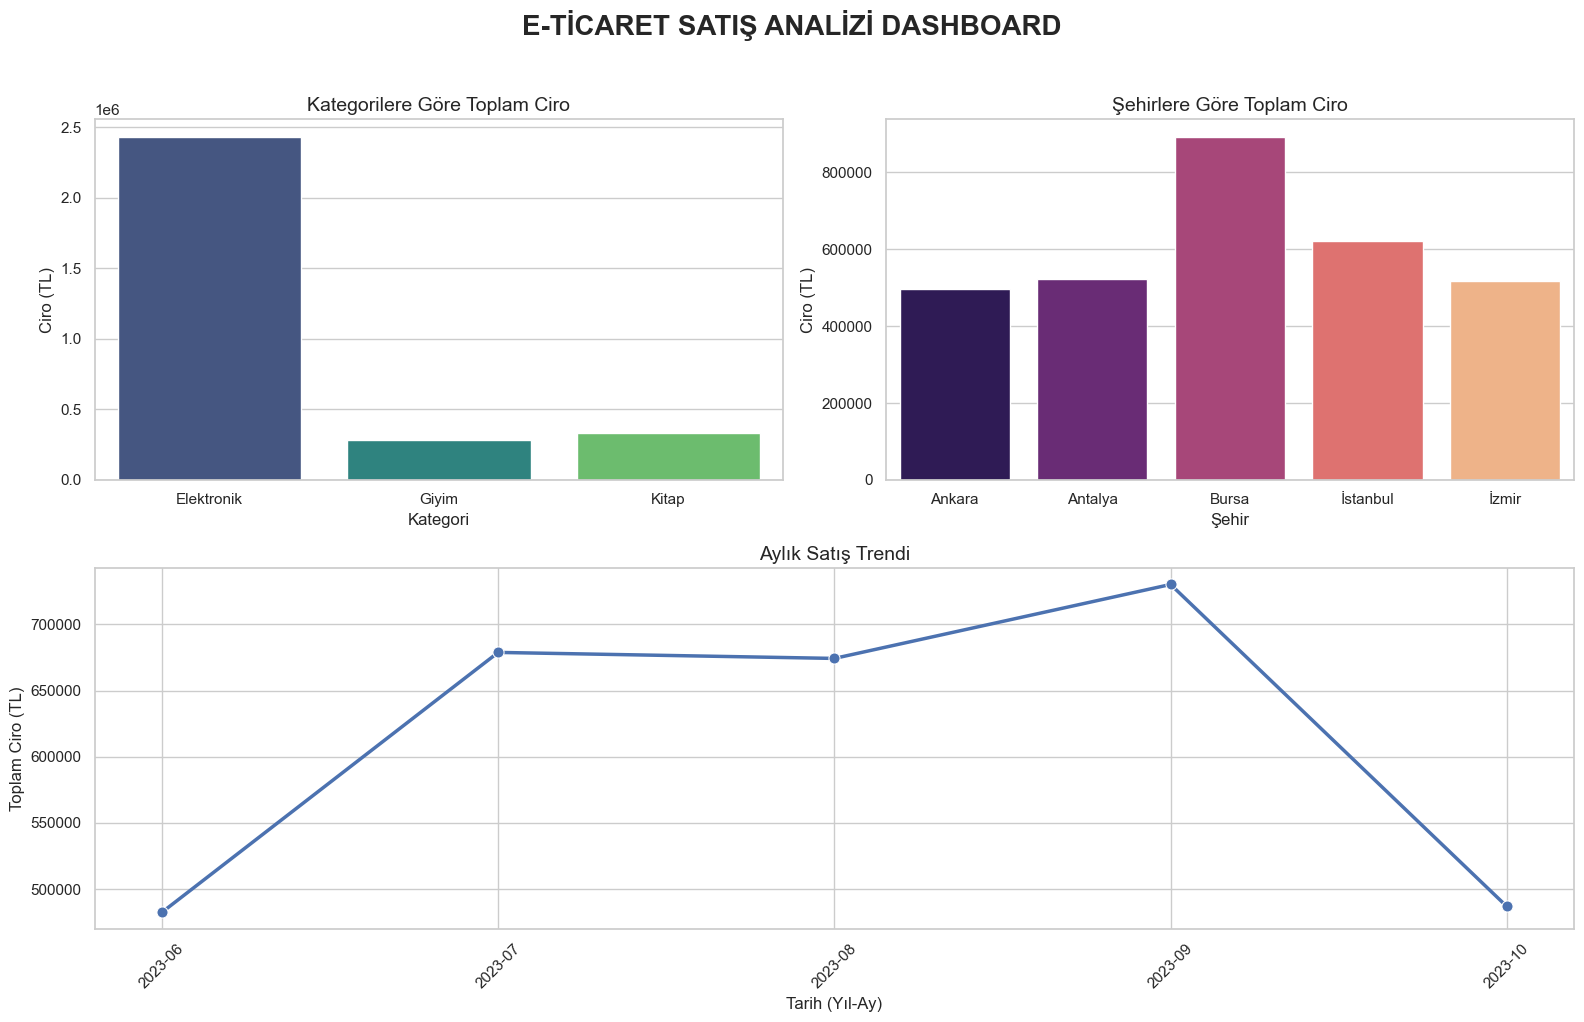

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Dashboard verisi okunuyor...")
df = pd.read_csv('Dashboard_Verisi.csv')

# Tarih sütununu datetime formatına çevirelim ki aylık trend çizebilelim
df['Siparis_Tarihi'] = pd.to_datetime(df['Siparis_Tarihi'])

# Grafik arka plan stilini belirleyelim
sns.set_theme(style="whitegrid")

# Tüm grafikleri tek bir pencerede (Dashboard) toplamak için figür oluşturuyoruz
fig = plt.figure(figsize=(16, 10))
fig.suptitle('E-TİCARET SATIŞ ANALİZİ DASHBOARD', fontsize=20, fontweight='bold', y=1.02)

# =========================================================
# 1. GRAFİK: Kategorilere Göre Toplam Ciro (Sol Üst)
# =========================================================
plt.subplot(2, 2, 1)
kategori_ciro = df.groupby('Kategori')['Toplam_Tutar'].sum().reset_index()
sns.barplot(data=kategori_ciro, x='Kategori', y='Toplam_Tutar', palette='viridis')
plt.title('Kategorilere Göre Toplam Ciro', fontsize=14)
plt.ylabel('Ciro (TL)')
plt.xlabel('Kategori')

# =========================================================
# 2. GRAFİK: Şehirlere Göre Ciro (Sağ Üst)
# =========================================================
plt.subplot(2, 2, 2)
sehir_ciro = df.groupby('Sehir')['Toplam_Tutar'].sum().reset_index()
sns.barplot(data=sehir_ciro, x='Sehir', y='Toplam_Tutar', palette='magma')
plt.title('Şehirlere Göre Toplam Ciro', fontsize=14)
plt.ylabel('Ciro (TL)')
plt.xlabel('Şehir')

# =========================================================
# 3. GRAFİK: Aylık Satış Trendi (Alt Taraf - Tam Boy)
# =========================================================
plt.subplot(2, 1, 2)
# Sadece Yıl ve Ay bilgisini alıyoruz (Örn: 2023-06)
df['Yil_Ay'] = df['Siparis_Tarihi'].dt.to_period('M').astype(str)
aylik_trend = df.groupby('Yil_Ay')['Toplam_Tutar'].sum().reset_index()

sns.lineplot(data=aylik_trend, x='Yil_Ay', y='Toplam_Tutar', marker='o', color='b', linewidth=2.5, markersize=8)
plt.title('Aylık Satış Trendi', fontsize=14)
plt.ylabel('Toplam Ciro (TL)')
plt.xlabel('Tarih (Yıl-Ay)')
plt.xticks(rotation=45)

# Grafikleri ekranda düzgün yerleştirmek için
plt.tight_layout()

# Dashboard'u resim olarak kaydetme
plt.savefig('Satis_Dashboard.png', bbox_inches='tight')
print("✅ Harika! Görselleştirme tamamlandı ve 'Satis_Dashboard.png' olarak kaydedildi.")

# Grafiği Jupyter ekranında gösterme
plt.show()